In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
equipment = pd.read_csv('/content/russia_losses_equipment.csv')
personnel = pd.read_csv('/content/russia_losses_personnel.csv')

# Check exact column names
print("Personnel columns:", personnel.columns.tolist())
print("\nEquipment columns:", equipment.columns.tolist())
print("\nPersonnel first 3 rows:")
print(personnel.head(3))

Personnel columns: ['date', 'day', 'personnel', 'personnel*', 'POW']

Equipment columns: ['date', 'day', 'aircraft', 'helicopter', 'tank', 'APC', 'field artillery', 'MRL', 'military auto', 'fuel tank', 'drone', 'naval ship', 'anti-aircraft warfare', 'special equipment', 'mobile SRBM system', 'greatest losses direction', 'vehicles and fuel tanks', 'cruise missiles', 'submarines']

Personnel first 3 rows:
         date   day  personnel personnel*  POW
0  2026-04-12  1509    1311180      about  NaN
1  2026-04-11  1508    1310110      about  NaN
2  2026-04-10  1507    1308670      about  NaN


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
equipment = pd.read_csv('/content/russia_losses_equipment.csv')
personnel = pd.read_csv('/content/russia_losses_personnel.csv')

# Convert types
personnel['date'] = pd.to_datetime(personnel['date'])
personnel['day'] = pd.to_numeric(personnel['day'], errors='coerce')
personnel['personnel'] = pd.to_numeric(personnel['personnel'], errors='coerce')
personnel['POW'] = pd.to_numeric(personnel['POW'], errors='coerce')

equipment['date'] = pd.to_datetime(equipment['date'])
equipment['day'] = pd.to_numeric(equipment['day'], errors='coerce')
equipment['tank'] = pd.to_numeric(equipment['tank'], errors='coerce')
equipment['aircraft'] = pd.to_numeric(equipment['aircraft'], errors='coerce')
equipment['helicopter'] = pd.to_numeric(equipment['helicopter'], errors='coerce')
equipment['drone'] = pd.to_numeric(equipment['drone'], errors='coerce')
equipment['APC'] = pd.to_numeric(equipment['APC'], errors='coerce')
equipment['naval ship'] = pd.to_numeric(equipment['naval ship'], errors='coerce')
equipment['MRL'] = pd.to_numeric(equipment['MRL'], errors='coerce')
equipment['field artillery'] = pd.to_numeric(equipment['field artillery'], errors='coerce')

# Sort by date
personnel = personnel.sort_values('date').reset_index(drop=True)
equipment = equipment.sort_values('date').reset_index(drop=True)

# Daily losses
personnel['daily_losses'] = personnel['personnel'].diff().fillna(0)

print("✅ Data cleaned successfully!")
print(f"Total days tracked: {personnel['day'].max()}")
print(f"Total personnel losses: {personnel['personnel'].max():,}")
print(f"Total tanks destroyed: {equipment['tank'].max():,}")
print(f"Total aircraft destroyed: {equipment['aircraft'].max():,}")
print(f"Total drones destroyed: {equipment['drone'].max():,}")

✅ Data cleaned successfully!
Total days tracked: 1509
Total personnel losses: 1,311,180
Total tanks destroyed: 11,859
Total aircraft destroyed: 435
Total drones destroyed: 233,866


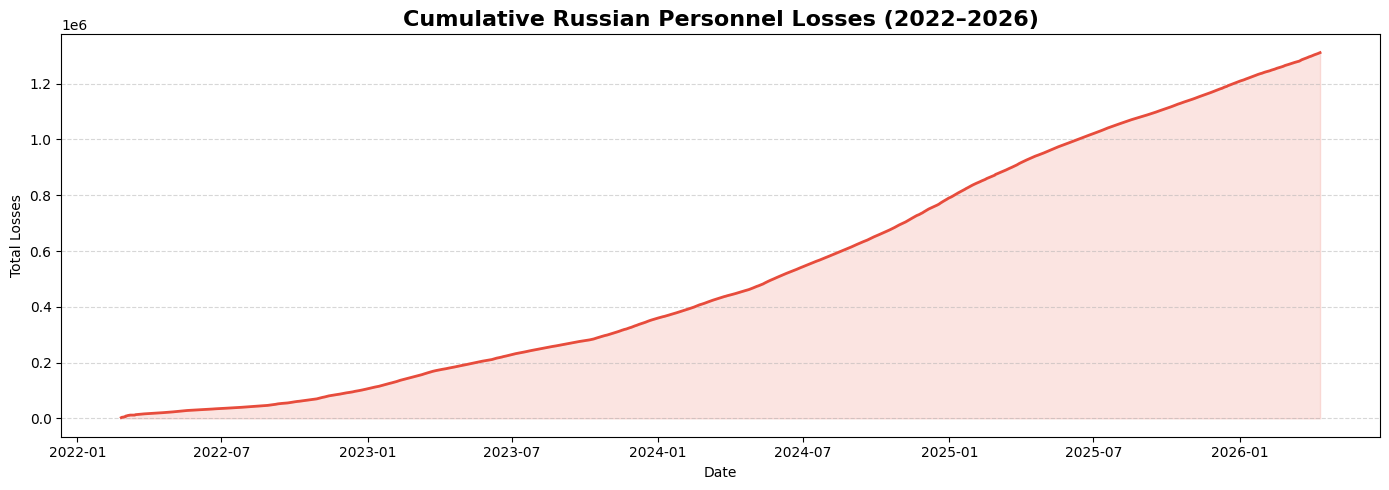

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(personnel['date'], personnel['personnel'],
         color='#e74c3c', linewidth=2)
plt.fill_between(personnel['date'], personnel['personnel'],
                 alpha=0.15, color='#e74c3c')
plt.title('Cumulative Russian Personnel Losses (2022–2026)',
          fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Losses')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('personnel_losses.png', dpi=150)
plt.show()

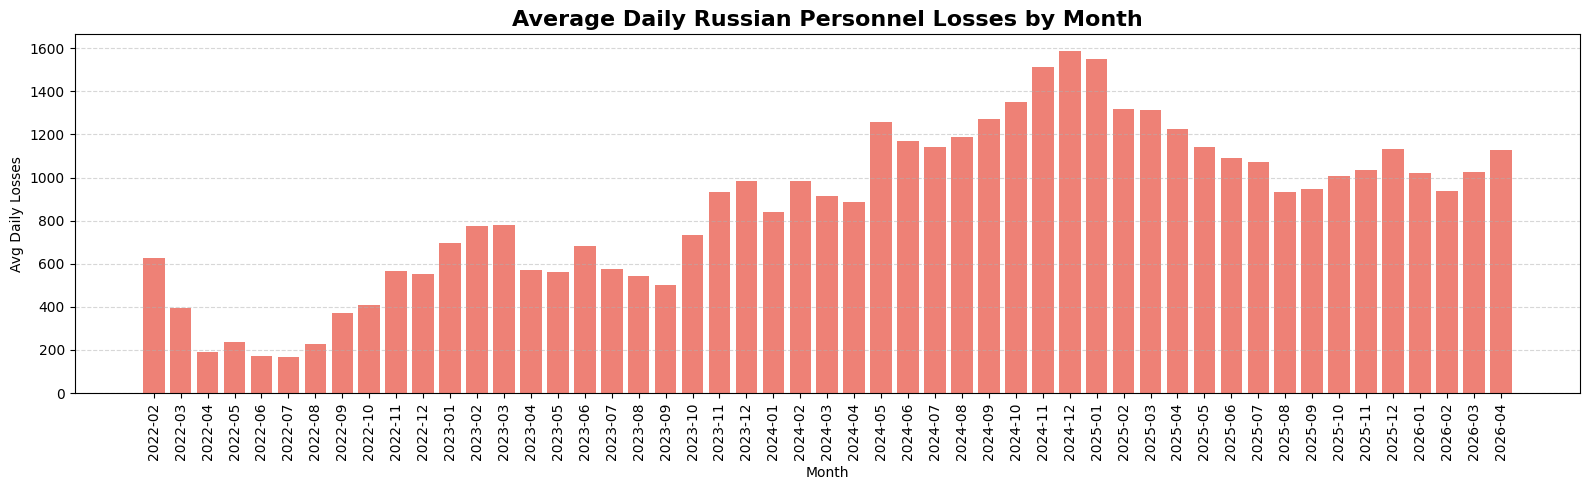

In [6]:
# Monthly average daily losses
personnel['month'] = personnel['date'].dt.to_period('M')
monthly = personnel.groupby('month')['daily_losses'].mean().reset_index()
monthly['month'] = monthly['month'].astype(str)

plt.figure(figsize=(16, 5))
plt.bar(monthly['month'], monthly['daily_losses'],
        color='#e74c3c', alpha=0.7)
plt.title('Average Daily Russian Personnel Losses by Month',
          fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Avg Daily Losses')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('daily_losses.png', dpi=150)
plt.show()

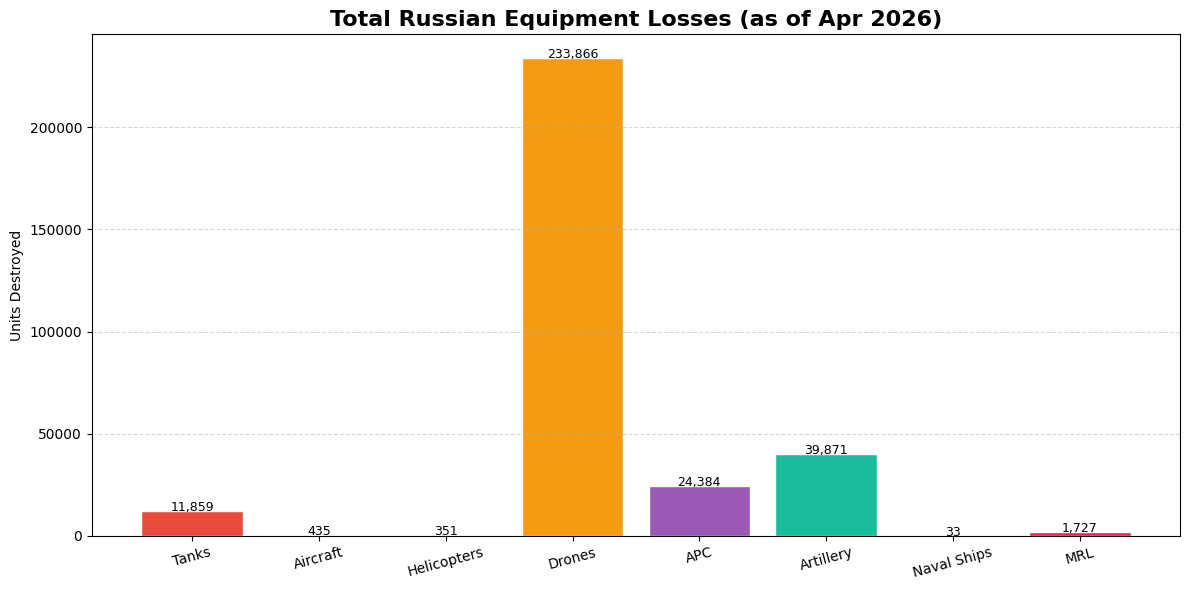

In [7]:
# Latest equipment totals
latest = equipment.iloc[-1]
eq_data = {
    'Tanks': latest['tank'],
    'Aircraft': latest['aircraft'],
    'Helicopters': latest['helicopter'],
    'Drones': latest['drone'],
    'APC': latest['APC'],
    'Artillery': latest['field artillery'],
    'Naval Ships': latest['naval ship'],
    'MRL': latest['MRL']
}

plt.figure(figsize=(12, 6))
bars = plt.bar(eq_data.keys(), eq_data.values(),
               color=['#e74c3c','#3498db','#2ecc71',
                      '#f39c12','#9b59b6','#1abc9c',
                      '#e67e22','#e91e63'],
               edgecolor='white')
plt.title('Total Russian Equipment Losses (as of Apr 2026)',
          fontsize=16, fontweight='bold')
plt.ylabel('Units Destroyed')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar, val in zip(bars, eq_data.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10,
             f'{int(val):,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('equipment_losses.png', dpi=150)
plt.show()


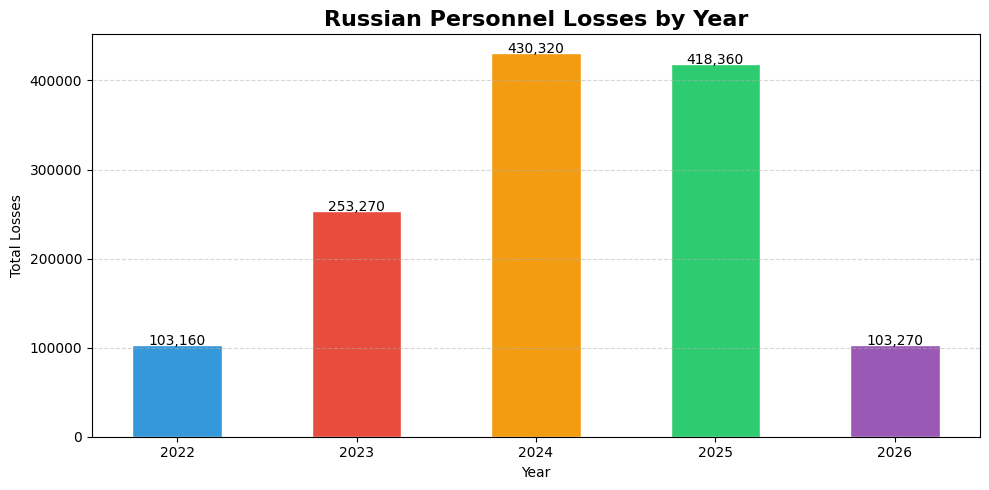

In [8]:
personnel['year'] = personnel['date'].dt.year
yearly = personnel.groupby('year').agg(
    total_losses=('daily_losses', 'sum')
).reset_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(yearly['year'].astype(str),
               yearly['total_losses'],
               color=['#3498db','#e74c3c','#f39c12',
                      '#2ecc71','#9b59b6'],
               edgecolor='white', width=0.5)
plt.title('Russian Personnel Losses by Year',
          fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Losses')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar, val in zip(bars, yearly['total_losses']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f'{int(val):,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('yearly_losses.png', dpi=150)
plt.show()


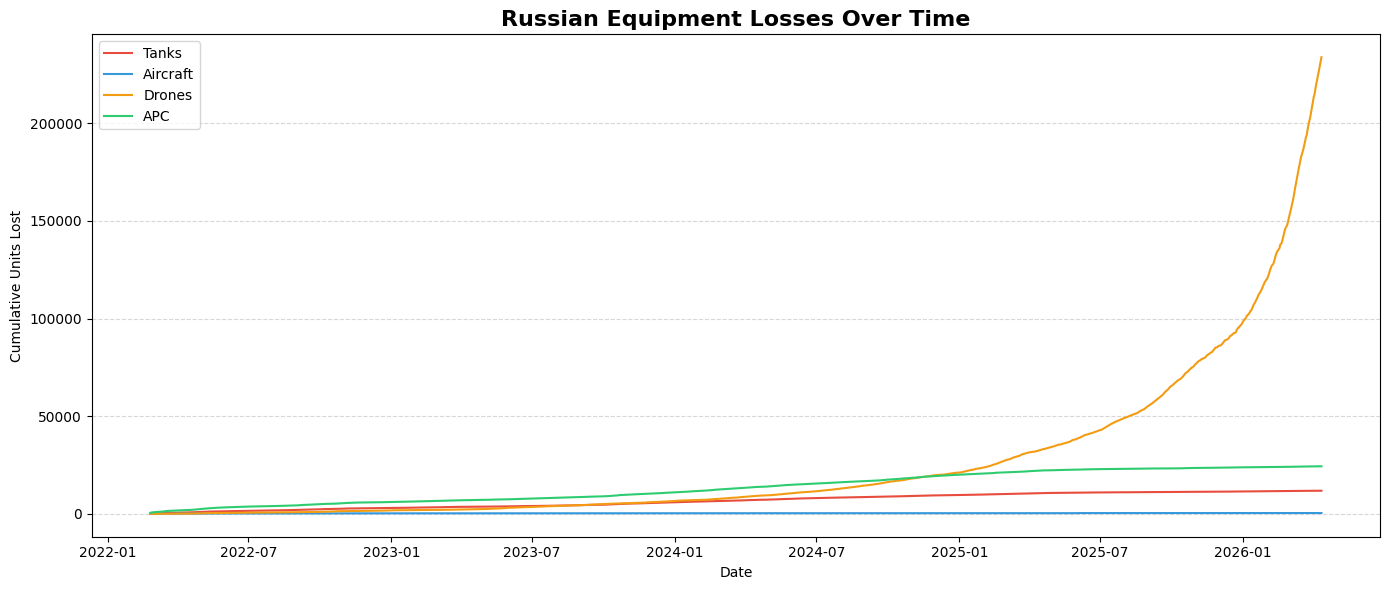

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(equipment['date'], equipment['tank'],
         label='Tanks', color='#e74c3c', linewidth=1.5)
plt.plot(equipment['date'], equipment['aircraft'],
         label='Aircraft', color='#3498db', linewidth=1.5)
plt.plot(equipment['date'], equipment['drone'],
         label='Drones', color='#f39c12', linewidth=1.5)
plt.plot(equipment['date'], equipment['APC'],
         label='APC', color='#2ecc71', linewidth=1.5)
plt.title('Russian Equipment Losses Over Time',
          fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Cumulative Units Lost')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('equipment_timeline.png', dpi=150)
plt.show()

In [11]:
print("=" * 50)
print("   RUSSIA-UKRAINE WAR — KEY STATISTICS")
print("=" * 50)
print(f"Days of conflict          : {int(personnel['day'].max())}")
print(f"Total personnel losses    : {int(personnel['personnel'].max()):,}")
print(f"Avg daily losses          : {personnel['daily_losses'].mean():.0f}")
print(f"Peak daily losses month   : {monthly.loc[monthly['daily_losses'].idxmax(), 'month']}")
print(f"Total tanks destroyed     : {int(equipment['tank'].max()):,}")
print(f"Total aircraft destroyed  : {int(equipment['aircraft'].max()):,}")
print(f"Total drones destroyed    : {int(equipment['drone'].max()):,}")
print(f"Total naval ships lost    : {int(equipment['naval ship'].max()):,}")
print("=" * 50)

   RUSSIA-UKRAINE WAR — KEY STATISTICS
Days of conflict          : 1509
Total personnel losses    : 1,311,180
Avg daily losses          : 868
Peak daily losses month   : 2024-12
Total tanks destroyed     : 11,859
Total aircraft destroyed  : 435
Total drones destroyed    : 233,866
Total naval ships lost    : 33


In [12]:

personnel.to_csv('personnel_clean.csv', index=False)
equipment.to_csv('equipment_clean.csv', index=False)

from google.colab import files
files.download('personnel_clean.csv')
files.download('equipment_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
# Check 2026 data
df_2026 = personnel[personnel['date'].dt.year == 2026]
print(df_2026[['date', 'personnel', 'daily_losses']].head(20))

           date  personnel  daily_losses
1406 2026-01-01    1208970        1060.0
1407 2026-01-02    1209880         910.0
1408 2026-01-03    1210630         750.0
1409 2026-01-04    1211530         900.0
1410 2026-01-05    1212520         990.0
1411 2026-01-06    1213460         940.0
1412 2026-01-07    1214500        1040.0
1413 2026-01-08    1215900        1400.0
1414 2026-01-09    1216930        1030.0
1415 2026-01-10    1217810         880.0
1416 2026-01-11    1218940        1130.0
1417 2026-01-12    1220000        1060.0
1418 2026-01-13    1220950         950.0
1419 2026-01-14    1221940         990.0
1420 2026-01-15    1223090        1150.0
1421 2026-01-16    1224460        1370.0
1422 2026-01-17    1225590        1130.0
1423 2026-01-18    1226420         830.0
1424 2026-01-19    1227440        1020.0
1425 2026-01-20    1228570        1130.0


In [14]:
from google.colab import files

files.download('personnel_losses.png')
files.download('daily_losses.png')
files.download('equipment_losses.png')
files.download('equipment_timeline.png')
files.download('yearly_losses.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>